# 02 — Variant 2: Pix2Pix (U-Net + PatchGAN + L1)

Adds the 70×70 PatchGAN discriminator on top of the L1 baseline.
Primary supervised model of the ablation.

In [1]:
import sys
sys.path.append("..")

import json
from pathlib import Path

import torch
from torch.utils.data import DataLoader

from src.data import AnimeColorizationDataset
from src.training import Pix2PixTrainer
from src.utils import seed_everything, plot_loss_curves, qualitative_grid, evaluate_model

seed_everything(42)

DATA_ROOT = Path("../data/anime_colorization")
CKPT_DIR = Path("../checkpoints/02_pix2pix")
FIG_DIR = Path("../results/figures")
TABLE_DIR = Path("../results/tables")

CONFIG = dict(
    image_size=256,
    batch_size=16,
    num_workers=8,
    epochs=50,
    lr=2e-4,
    lambda_l1=100.0,
    lambda_gan=1.0,
    lambda_perceptual=0.0,
)

## Data

AnimeColorizationDatasets + paired DataLoaders for every split (train, val, test).

In [2]:
splits = {split: AnimeColorizationDataset(DATA_ROOT, split=split,
                                          image_size=CONFIG["image_size"])
          for split in ("train", "val", "test")}

train_loader = DataLoader(splits["train"], batch_size=CONFIG["batch_size"],
                          shuffle=True, num_workers=CONFIG["num_workers"],
                          pin_memory=True, drop_last=True, persistent_workers=True)
val_loader = DataLoader(splits["val"], batch_size=CONFIG["batch_size"],
                        shuffle=False, num_workers=CONFIG["num_workers"],
                        pin_memory=True, persistent_workers=True)
test_loader = DataLoader(splits["test"], batch_size=CONFIG["batch_size"],
                         shuffle=False, num_workers=CONFIG["num_workers"],
                         pin_memory=True, persistent_workers=True)

for split, ds in splits.items():
    print(f"{split:5s}: {len(ds):6d} images")

train:  14224 images
val  :   1772 images
test :   1773 images


## Training

`Pix2PixTrainer` with `lambda_gan=1`: U-Net generator + PatchGAN discriminator + L1. Best checkpoint selected by `val_l1`. Resume by uncommenting `load_checkpoint`.

In [3]:
trainer = Pix2PixTrainer(
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_dir=CKPT_DIR,
    lr=CONFIG["lr"],
    lambda_l1=CONFIG["lambda_l1"],
    lambda_gan=CONFIG["lambda_gan"],
    lambda_perceptual=CONFIG["lambda_perceptual"],
)

# To resume an interrupted run, uncomment:
# trainer.load_checkpoint("last.pt")

history = trainer.fit(CONFIG["epochs"])

epoch 1/50 [train]:   0%|          | 0/889 [00:00<?, ?it/s]

epoch 1/50 [val]:   0%|          | 0/111 [00:00<?, ?it/s]

epoch   1/50 | train_d=0.2907 | train_l1=0.2004 | train_gan=2.9311 | train_g=22.9706 | val_l1=0.1793


epoch 2/50 [train]:   0%|          | 0/889 [00:00<?, ?it/s]

epoch 2/50 [val]:   0%|          | 0/111 [00:00<?, ?it/s]

...

epoch 49/50 [val]:   0%|          | 0/111 [00:00<?, ?it/s]

epoch  49/50 | train_d=0.2804 | train_l1=0.0801 | train_gan=3.0708 | train_g=11.0785 | val_l1=0.1505


epoch 50/50 [train]:   0%|          | 0/889 [00:00<?, ?it/s]

epoch 50/50 [val]:   0%|          | 0/111 [00:00<?, ?it/s]

epoch  50/50 | train_d=0.2588 | train_l1=0.0795 | train_gan=3.0758 | train_g=11.0283 | val_l1=0.1517


In [1]:
trainer.load_checkpoint("last.pt")
plot_loss_curves(trainer.history, title="Variant 2 — Pix2Pix (U-Net + PatchGAN + L1)",
                 save_path=FIG_DIR / "02_pix2pix_losses.png")

NameError: name 'trainer' is not defined

## Qualitative results

Best checkpoint (lowest `val_l1`), random test batch: sketch | prediction | ground truth. Expect sharper, more saturated colors compared to the L1-only baseline thanks to the adversarial signal.

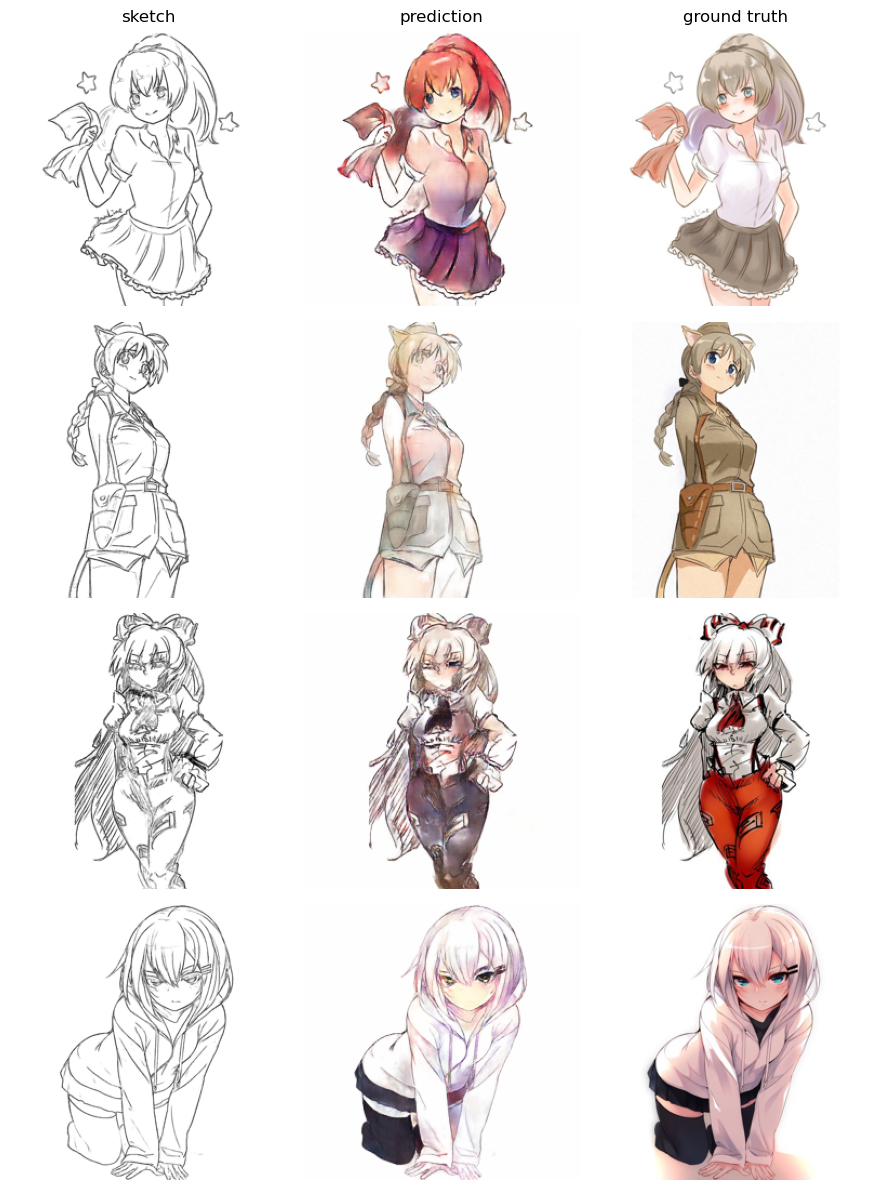

In [5]:
trainer.load_checkpoint("best.pt")

batch = next(iter(test_loader))
prediction = trainer.generate(batch["sketch"])
qualitative_grid(batch["sketch"], prediction, batch["color"], n_rows=4,
                 save_path=FIG_DIR / "02_pix2pix_grid.png")

## Quantitative evaluation (test set)

PSNR / SSIM / LPIPS / FID on the full test split, saved to `results/tables/02_pix2pix.json`.

In [6]:
metrics = evaluate_model(trainer.generator, test_loader,
                         fid_dir="../results/fid/02_pix2pix")
print(metrics)

TABLE_DIR.mkdir(parents=True, exist_ok=True)
with open(TABLE_DIR / "02_pix2pix.json", "w") as f:
    json.dump({"variant": "02_pix2pix", "config": CONFIG, "metrics": metrics}, f, indent=2)

/home/mmondo/miniconda3/envs/anime-colorization/lib/python3.10/site-packages/torchmetrics/functional/image/lpips.py:332: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.l

evaluate:   0%|          | 0/111 [00:00<?, ?it/s]

100%|██████████| 36/36 [00:03<00:00, 10.21it/s]


{'psnr': 16.26393699645996, 'ssim': 0.7997269630432129, 'lpips': 0.19099029898643494, 'fid': np.float64(49.12768922288399)}
